# Task 1: Exploring and Visualizing the Iris Dataset

**Student Name:** Yusra Waheed  
**Date:** June 8, 2026  
**Organization:** DevelopersHub Corporation  
**Task Title:** Exploring and Visualizing the Iris Dataset

---

## SECTION 1 — PROBLEM STATEMENT & GOAL

### What is the Iris dataset?
The Iris dataset is a classic dataset in machine learning and statistics. It was introduced by the British statistician and biologist Ronald Fisher in 1936. The dataset contains 150 samples of Iris flowers from three different species: **Setosa**, **Versicolor**, and **Virginica**. For each sample, four features were measured in centimeters:
1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

### What is the goal of this task?
The primary goal is to perform a comprehensive **Exploratory Data Analysis (EDA)**. We aim to inspect the data's structure, identify patterns, detect outliers, and visualize the relationships between features to see how they distinguish the different species.

### What skills will be demonstrated?
- Data loading and manipulation using **Pandas**.
- Statistical summary and data profiling.
- Data visualization using **Matplotlib** and **Seaborn**.
- Drawing analytical insights from visual patterns.

---

## SECTION 2 — IMPORT LIBRARIES

In this section, we import the essential Python libraries for data science. 

In [ ]:
import pandas as pd      # For data manipulation and analysis
import seaborn as sns    # For high-level statistical data visualization
import matplotlib.pyplot as plt  # For creating static and interactive visualizations
import numpy as np       # For numerical computations and array handling
import os                # For directory management

# Ensure plots are displayed inline in the notebook
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


---

## SECTION 3 — DATASET LOADING & INSPECTION

We will load the dataset directly from Seaborn's built-in datasets and perform an initial sanity check.

In [2]:
# Load the Iris dataset
df = sns.load_dataset('iris')

# Create plots directory if it doesn't exist
if not os.path.exists('../plots'):
    os.makedirs('../plots')

print("Dataset loaded and 'plots' directory verified.")

Dataset loaded and 'plots' directory verified.


### 3a. Shape and Columns
Let's check the dimensions of our dataset and the names of the features.

In [3]:
# Check shape and column names
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


**Explanation:** The output shows that the dataset contains **150 rows** (samples) and **5 columns** (4 features + 1 target class). The columns represent sepal and petal measurements and the species name.

### 3b. First 5 Rows
Viewing the first few rows helps us understand the data format.

In [4]:
# Display the first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Explanation:** The `.head()` function shows that all features are numerical (float), and the species column is a categorical string.

### 3c. Data Information and Null Values
We need to ensure there are no missing values and check the data types.

In [5]:
# Show data types and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


**Explanation:** The `.info()` output confirms that there are **zero null values** in the dataset, which is ideal for analysis. All measurement columns are `float64`, and the species is an `object`.

### 3d. Statistical Summary
This provides an overview of the distribution of our numerical features.

In [6]:
# Display statistical summary
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Explanation:** The statistical summary shows the mean, standard deviation, and range for each feature. For example, sepal length varies from 4.3 cm to 7.9 cm.

### 3e. Species Distribution
It is important to check if the dataset is balanced.

In [7]:
# Show species value counts
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Explanation:** The dataset is perfectly balanced, with exactly **50 samples for each species**.

---

## SECTION 4 — DATA VISUALIZATION

Visualization is key to understanding the underlying patterns in the data.

### 4a. Scatter Plot: Sepal Length vs Petal Length
We will explore the relationship between sepal length and petal length.

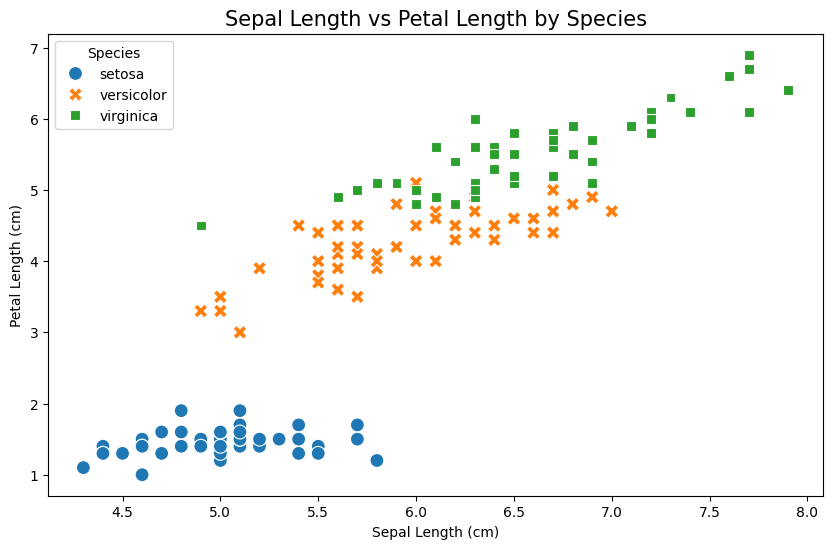

In [8]:
# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal_length', y='petal_length', hue='species', style='species', s=100)
plt.title('Sepal Length vs Petal Length by Species', fontsize=15)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species')

# Save the plot
plt.savefig('../plots/scatter_plot.png', dpi=300)
plt.show()

**Findings:** 
- **Setosa** forms a distinct cluster with much smaller petal lengths compared to its sepal length.
- **Versicolor** and **Virginica** show a linear trend but have some overlap between them.

### 4b. Histograms: Feature Distributions
We will examine the distribution of all four measurements.

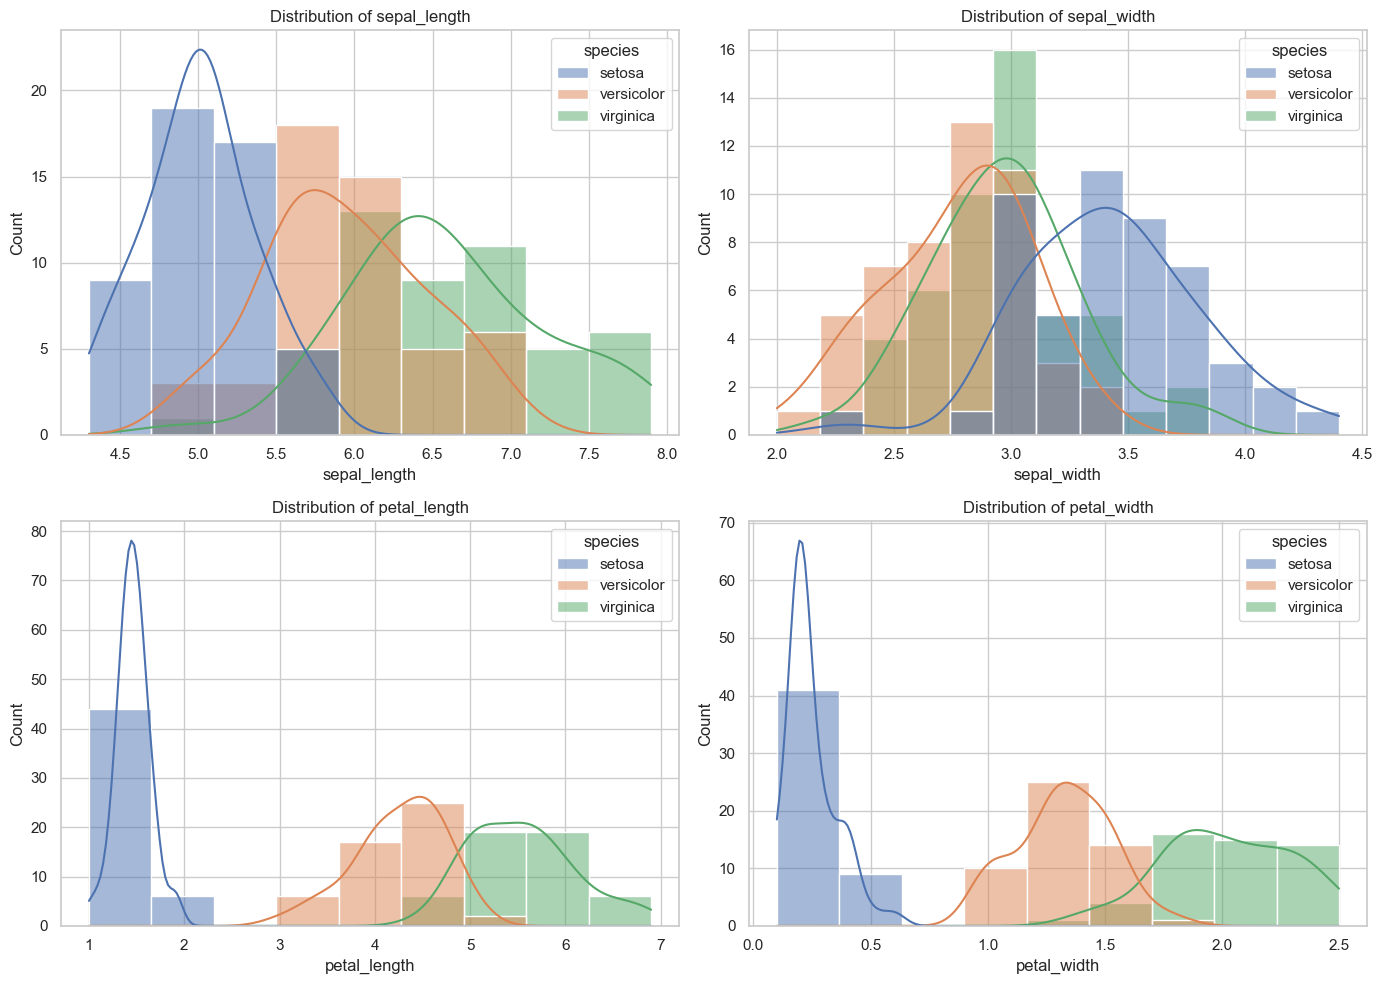

In [9]:
# Set plot style
sns.set_theme(style="whitegrid")

# Create 2x2 grid for histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = df.columns[:-1]

for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, kde=True, hue='species', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Distribution of {feature}', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/histograms.png', dpi=300)
plt.show()

**Findings:**
- **Petal measurements** (Length and Width) show clear gaps between Setosa and the other species, suggesting they are better for classification.
- **Sepal measurements** have significant overlap across all three species.

### 4c. Box Plots: Outlier Detection
Box plots help us see the spread and identify outliers for each species.

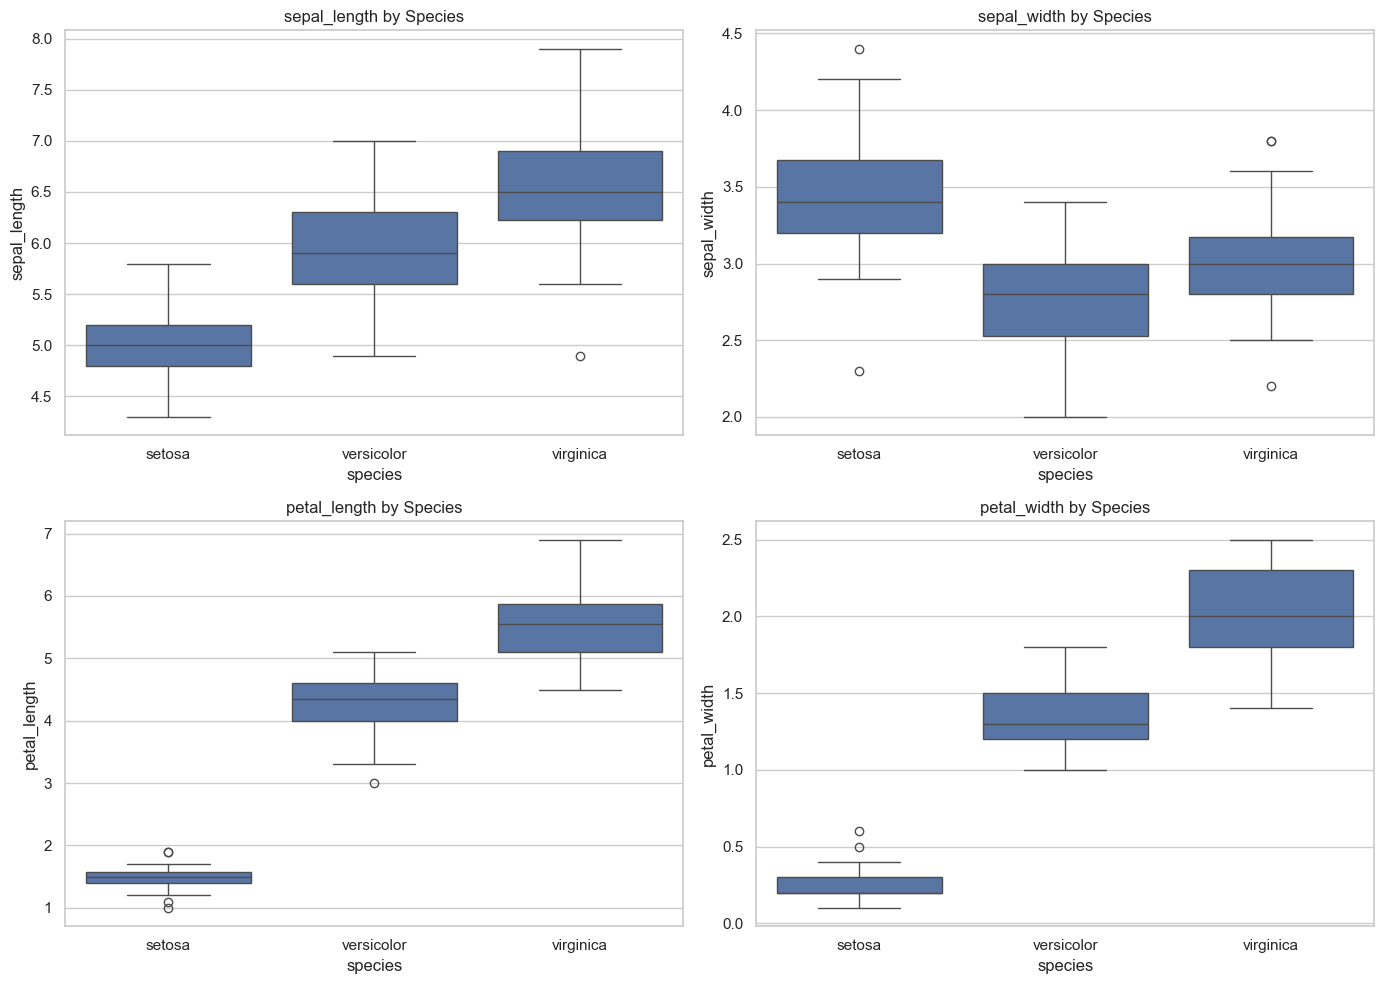

In [10]:
# Create 2x2 grid for box plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='species', y=feature, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{feature} by Species', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/boxplots.png', dpi=300)
plt.show()

**Findings:**
- **Setosa** has the smallest petals and narrowest range of measurements.
- **Sepal Width** shows a few outliers for the Setosa species (points beyond the whiskers).

### 4d. Bonus: Pair Plot
A pair plot allows us to see relationships between all features simultaneously.

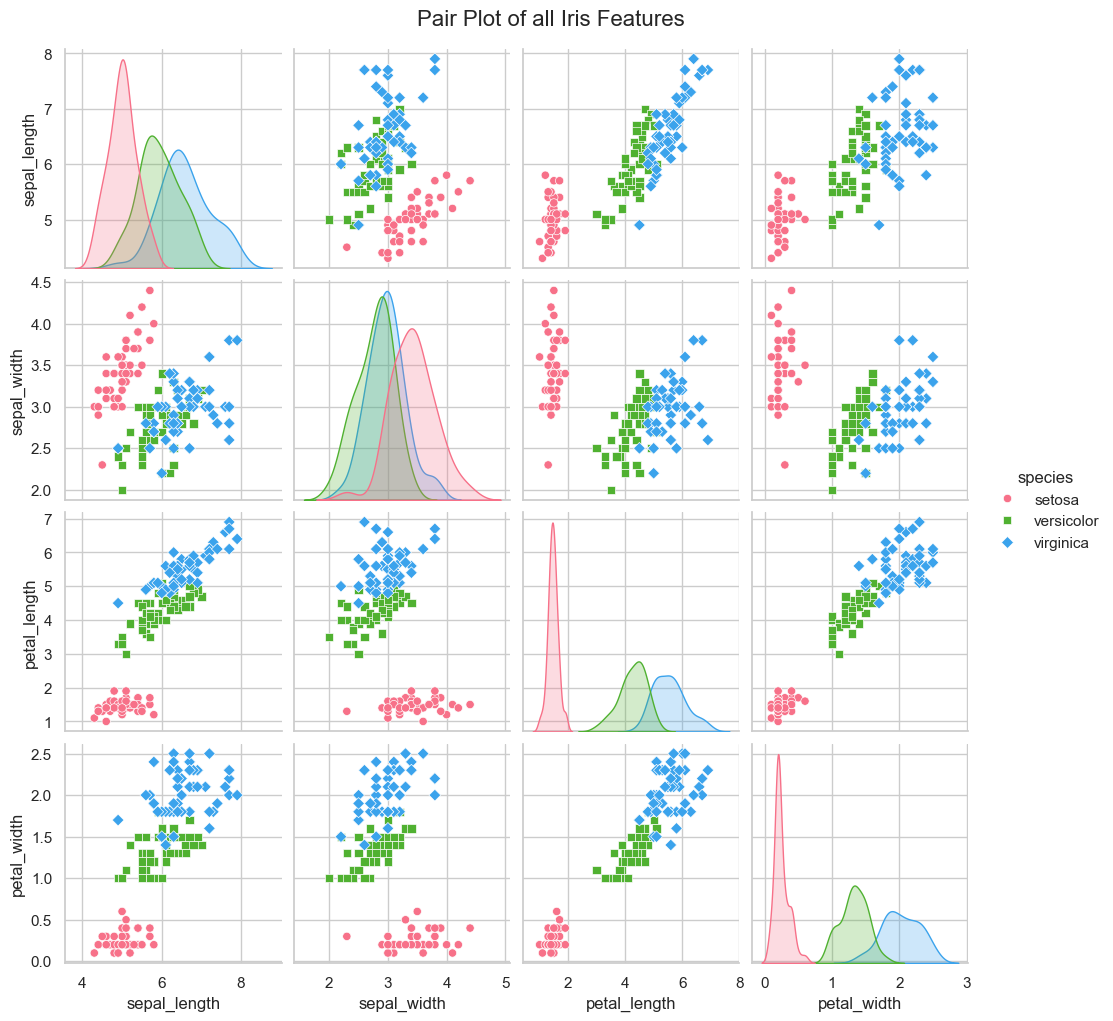

In [11]:
# Create pair plot
pair_plot = sns.pairplot(df, hue='species', palette='husl', markers=["o", "s", "D"])
pair_plot.fig.suptitle('Pair Plot of all Iris Features', y=1.02, fontsize=16)

# Save plot
pair_plot.savefig('../plots/pairplot.png', dpi=300)
plt.show()

**Findings:**
- The pair plot confirms that **Petal Length** and **Petal Width** are highly correlated.
- Setosa is linearly separable from Versicolor and Virginica using almost any pair of features involving petal measurements.

---

## SECTION 5 — KEY INSIGHTS & CONCLUSION

### What patterns were found?
1. **Species Separation:** Setosa is highly distinct from Versicolor and Virginica. Versicolor and Virginica share more similar traits but are still distinguishable.
2. **Feature Correlation:** Petal length and petal width show a very strong positive correlation.

### Which features best separate the species?
**Petal Length** and **Petal Width** are the most significant features for separating these species. Setosa has distinctly smaller values for these, while Virginica generally has the largest.

### What did we learn from this analysis?
We learned that the Iris dataset is a very clean and balanced dataset. The features provided are excellent for classification tasks, as at least one species is easily separable from the others.

### How does this help in ML model building?
- Since the features (especially petals) show clear separation, simple models like **Logistic Regression** or **Decision Trees** should perform very well.
- Because of the overlap between Versicolor and Virginica, we might need a non-linear classifier or more complex features if 100% accuracy is required.
- The lack of missing values and outliers (except for a few in sepal width) means minimal preprocessing is needed.